In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

/home/nkminion/miniconda3/envs/PyTorchVenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
BinaryTargetEncoder = LabelEncoder()
CategoricalTargetEncoder = LabelEncoder()

In [6]:
TrainDataset = pd.read_csv('TrainDataset.csv')

TextFeatures = TrainDataset.select_dtypes(include=['object']).columns.drop('attack_cat')
TrainDataset[TextFeatures] = TrainDataset[TextFeatures].astype('category')
TrainDataset['label'] = BinaryTargetEncoder.fit_transform(TrainDataset['label'])

TrainX = TrainDataset.drop(columns=['id','label','attack_cat'])
TrainY = TrainDataset['label']

CatIndices = [TrainX.columns.get_loc(col) for col in TextFeatures]
for col in TextFeatures:
	TrainX[col] = TrainX[col].astype('category')
	
smotenc = SMOTENC(categorical_features=CatIndices, sampling_strategy='auto')

TrainXMI = TrainX.copy()
for col in TextFeatures:
	TrainXMI[col] = TrainXMI[col].cat.codes 

TrainMIScores = mutual_info_classif(TrainXMI, TrainY, random_state=7)
TrainMIDF = pd.DataFrame(TrainMIScores, index=TrainX.columns, columns=['TrainMIScore']).sort_values(by='TrainMIScore', ascending=False)

LowMIFeatures = TrainMIDF[TrainMIDF['TrainMIScore'] < 0.01].index

TrainCorrelationMatrix = TrainXMI.corr().abs()
TrainUpperTriangle = TrainCorrelationMatrix.where(np.triu(np.ones(TrainCorrelationMatrix.shape), k=1).astype(bool))
RedundantFeatures = set()
for col in TrainUpperTriangle.columns:
	for row in TrainUpperTriangle.index:
		if TrainUpperTriangle.loc[row,col] > 0.90:
			if TrainMIDF.loc[row,'TrainMIScore'] > TrainMIDF.loc[col,'TrainMIScore']:
				RedundantFeatures.add(col)
			else:
				RedundantFeatures.add(row)

FeaturesToDrop = set(LowMIFeatures) | RedundantFeatures
TrainX.drop(columns=list(FeaturesToDrop), inplace=True)
TrainMIDF.drop(index=list(FeaturesToDrop), inplace=True)

/tmp/ipykernel_1498240/2387836192.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  TextFeatures = TrainDataset.select_dtypes(include=['object']).columns.drop('attack_cat')


In [7]:
TrainAttackIndices = TrainY == 1
TrainXAttackOnly = TrainX[TrainAttackIndices]

TrainOriginalAttackIndices = (TrainDataset['label'] == 1)
TrainXAttackOnly = TrainX.iloc[:len(TrainDataset)][TrainOriginalAttackIndices]
TrainYAttackOnly = CategoricalTargetEncoder.fit_transform(TrainDataset.loc[TrainOriginalAttackIndices, 'attack_cat'])

CategoricalWeights = compute_sample_weight(class_weight='balanced', y=TrainYAttackOnly)

In [8]:
TestDataset = pd.read_csv('TestDataset.csv')

TestDataset[TextFeatures] = TestDataset[TextFeatures].astype('category')
TestDataset['label'] = BinaryTargetEncoder.transform(TestDataset['label'])

TestX = TestDataset.drop(columns=['id','label','attack_cat'])
TestY = TestDataset['label']
TestX.drop(columns=list(FeaturesToDrop), inplace=True)

In [9]:
TestAttackIndices = TestDataset['label'] == 1
TestXAttackOnly = TestX[TestAttackIndices]
TestYAttackOnly = CategoricalTargetEncoder.transform(TestDataset.loc[TestAttackIndices,'attack_cat'])

NewCatIndices = [TrainXAttackOnly.columns.get_loc(col) for col in TextFeatures]

CatSmotenc = SMOTENC(categorical_features=NewCatIndices, sampling_strategy='auto')

for col in TextFeatures:
	TrainXAttackOnly[col] = TrainXAttackOnly[col].astype('category')

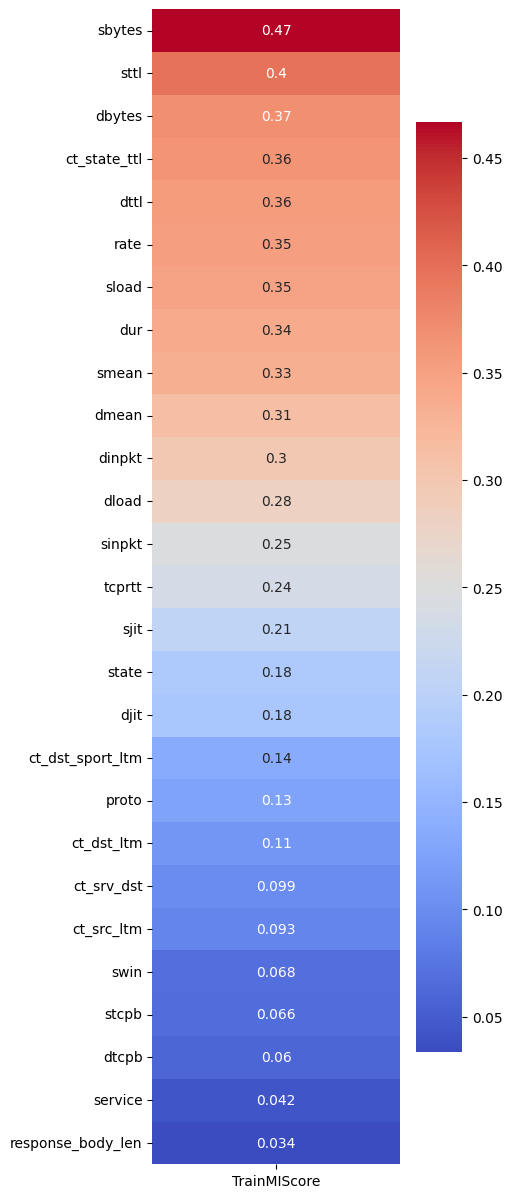

In [10]:
plt.figure(figsize=(4, 15))
sns.heatmap(TrainMIDF, cmap='coolwarm', annot=True)
plt.show()

In [28]:
XTrain, XVal, YTrain, YVal = train_test_split(TrainX, TrainY, test_size=0.15)
TrainXResampled, TrainY_resampled = smotenc.fit_resample(TrainX, TrainY)

XTrain = pd.DataFrame(TrainXResampled, columns=TrainX.columns)
YTrain = pd.Series(TrainY_resampled)

def BinaryTrain(trial):
	param = {
		'max_depth': trial.suggest_int('max_depth', 3, 12),
		'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
		'n_estimators': trial.suggest_int('n_estimators', 50, 300),
		'min_child_weight': trial.suggest_int('min_child_weight', 1, 7)
	}

	BinaryModel = xgb.XGBClassifier(
		**param,
		enable_categorical=True,
		eval_metric='logloss',
		early_stopping_rounds=15,
		device='cuda',
		tree_method='hist'
	)

	BinaryModel.fit(XTrain, YTrain, eval_set=[(XVal, YVal)], verbose=False)
	return accuracy_score(YVal, BinaryModel.predict(XVal))

BinaryStudy = optuna.create_study(direction='maximize')
BinaryStudy.optimize(BinaryTrain, n_trials=100)

PosWeight = (TrainY == 0).sum() / (TrainY == 1).sum()

BinaryModel = xgb.XGBClassifier(
	**BinaryStudy.best_params,
	enable_categorical=True,
	scale_pos_weight=PosWeight,
	device='cuda',
	tree_method='hist'
)
BinaryModel.fit(TrainX, TrainY)

[I 2026-08-29 22:25:40,540] A new study created in memory with name: no-name-9ed10a77-19ac-482e-a331-e368a1d61bb6
[I 2026-08-29 22:25:41,351] Trial 0 finished with value: 0.9460117101361113 and parameters: {'max_depth': 7, 'learning_rate': 0.02755379920753178, 'n_estimators': 269, 'min_child_weight': 5}. Best is trial 0 with value: 0.9460117101361113.
[I 2026-08-29 22:25:41,684] Trial 1 finished with value: 0.9482168656375941 and parameters: {'max_depth': 10, 'learning_rate': 0.08709311010618087, 'n_estimators': 52, 'min_child_weight': 2}. Best is trial 1 with value: 0.9482168656375941.
[I 2026-08-29 22:25:42,133] Trial 2 finished with value: 0.9373431678199377 and parameters: {'max_depth': 10, 'learning_rate': 0.015069630212257356, 'n_estimators': 62, 'min_child_weight': 2}. Best is trial 1 with value: 0.9482168656375941.
[I 2026-08-29 22:25:42,525] Trial 3 finished with value: 0.9319823587559881 and parameters: {'max_depth': 3, 'learning_rate': 0.017818060540143163, 'n_estimators': 2

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [29]:
XTrainAtt, XValAtt, YTrainAtt, YValAtt = train_test_split(TrainXAttackOnly, TrainYAttackOnly, test_size=0.15, random_state=7)
TrainXAttResampled, TrainYAttResampled = CatSmotenc.fit_resample(XTrainAtt, YTrainAtt)

XTrainAtt = pd.DataFrame(TrainXAttResampled, columns=TrainXAttackOnly.columns)
YTrainAtt = pd.Series(TrainYAttResampled)

def CategoricalTrain(trial):
	param = {
		'max_depth': trial.suggest_int('max_depth', 3, 12),
		'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
		'n_estimators': trial.suggest_int('n_estimators', 50, 300),
		'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
		'max_delta_step': trial.suggest_int('max_delta_step', 1, 10)
	}

	CategoricalModel = xgb.XGBClassifier(
		**param,
		enable_categorical=True,
		objective='multi:softprob',
		eval_metric='mlogloss',
		early_stopping_rounds=15,
		device='cuda',
		tree_method='hist'
	)

	CategoricalModel.fit(XTrainAtt, YTrainAtt, eval_set=[(XValAtt, YValAtt)], verbose=False)
	return f1_score(YValAtt, CategoricalModel.predict(XValAtt), average='macro')

CategoricalStudy = optuna.create_study(direction='maximize')
CategoricalStudy.optimize(CategoricalTrain, n_trials=100)

CategoricalModel = xgb.XGBClassifier(
    **CategoricalStudy.best_params,
	objective='multi:softprob',
	eval_metric='mlogloss',
    enable_categorical=True,
	device='cuda',
	tree_method='hist'
)
CategoricalModel.fit(TrainXAttackOnly, TrainYAttackOnly)

[I 2026-08-29 22:28:43,345] A new study created in memory with name: no-name-4aa09798-7988-48b8-99a9-70ec6127c385
[I 2026-08-29 22:28:45,884] Trial 0 finished with value: 0.5102592228206335 and parameters: {'max_depth': 8, 'learning_rate': 0.015060129922918832, 'n_estimators': 59, 'min_child_weight': 1, 'max_delta_step': 7}. Best is trial 0 with value: 0.5102592228206335.
[I 2026-08-29 22:28:54,100] Trial 1 finished with value: 0.5258369182293285 and parameters: {'max_depth': 9, 'learning_rate': 0.01643347964476075, 'n_estimators': 157, 'min_child_weight': 2, 'max_delta_step': 8}. Best is trial 1 with value: 0.5258369182293285.
[I 2026-08-29 22:28:57,863] Trial 2 finished with value: 0.5638976751136993 and parameters: {'max_depth': 6, 'learning_rate': 0.2787130811960831, 'n_estimators': 235, 'min_child_weight': 7, 'max_delta_step': 4}. Best is trial 2 with value: 0.5638976751136993.
[I 2026-08-29 22:29:00,797] Trial 3 finished with value: 0.5378998786460962 and parameters: {'max_depth'

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [32]:
BinaryModel.save_model('BinaryXGB.json')
CategoricalModel.save_model('CategoricalXGB.json')

In [11]:
BinaryLoaded = xgb.XGBClassifier()
BinaryLoaded.load_model('BinaryXGB.json')

CategoricalLoaded = xgb.XGBClassifier()
CategoricalLoaded.load_model('CategoricalXGB.json')

In [12]:
# Binary Validation
print(f'Overall Accuracy (Binary): {accuracy_score(TestY, BinaryLoaded.predict(TestX))*100:.2f}%')
print(classification_report(TestY, BinaryLoaded.predict(TestX), target_names=['Normal','Attack']))

Overall Accuracy (Binary): 87.35%
              precision    recall  f1-score   support

      Normal       0.94      0.77      0.85     37000
      Attack       0.84      0.96      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.87     82332
weighted avg       0.88      0.87      0.87     82332



In [13]:
# Categorical Validation
print(f'Overall Accuracy (Categorical): {accuracy_score(TestYAttackOnly, CategoricalLoaded.predict(TestXAttackOnly))*100:.2f}%')
print(classification_report(TestYAttackOnly, CategoricalLoaded.predict(TestXAttackOnly), target_names=CategoricalTargetEncoder.classes_))

Overall Accuracy (Categorical): 79.56%
                precision    recall  f1-score   support

      Analysis       0.08      0.08      0.08       677
      Backdoor       0.03      0.11      0.04       583
           DoS       0.57      0.12      0.20      4089
      Exploits       0.65      0.83      0.73     11132
       Fuzzers       0.90      0.78      0.84      6062
       Generic       1.00      0.97      0.99     18871
Reconnaissance       0.93      0.81      0.87      3496
     Shellcode       0.60      0.67      0.63       378
         Worms       0.63      0.43      0.51        44

      accuracy                           0.80     45332
     macro avg       0.60      0.53      0.54     45332
  weighted avg       0.83      0.80      0.79     45332



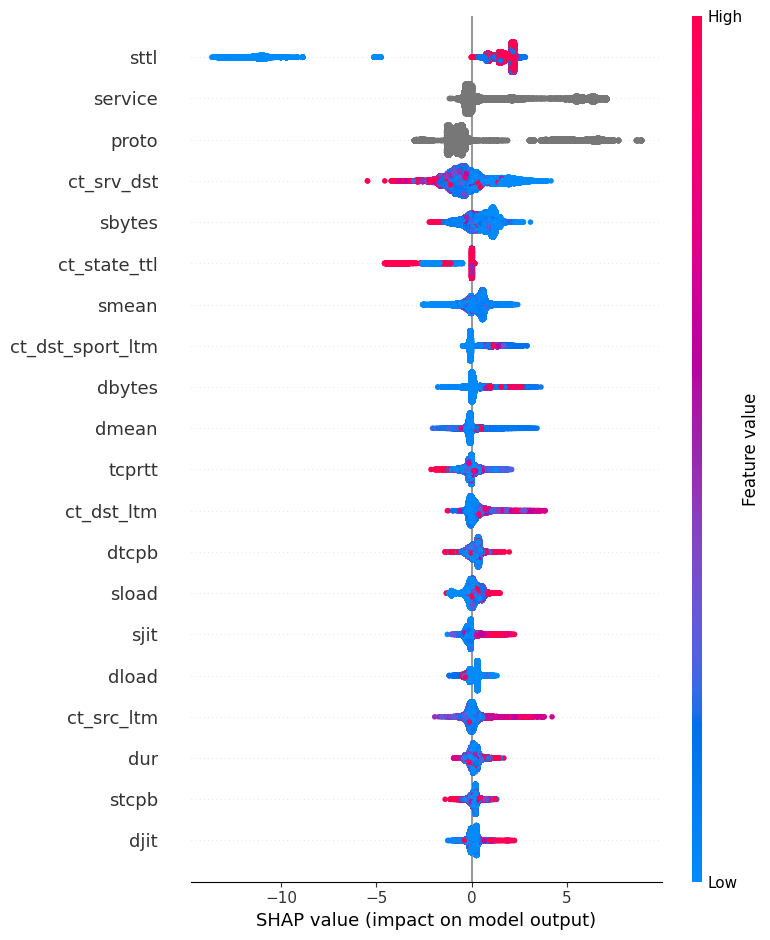

In [14]:
TestBinDMatrix = xgb.DMatrix(TestX, enable_categorical=True)
BinBooster = BinaryLoaded.get_booster()
BinBooster.set_param({'device': 'cuda'})
ShapBinContrib = BinBooster.predict(TestBinDMatrix, pred_contribs=True)
ShapBinVals = ShapBinContrib[:, :-1]
shap.summary_plot(ShapBinVals, TestX)

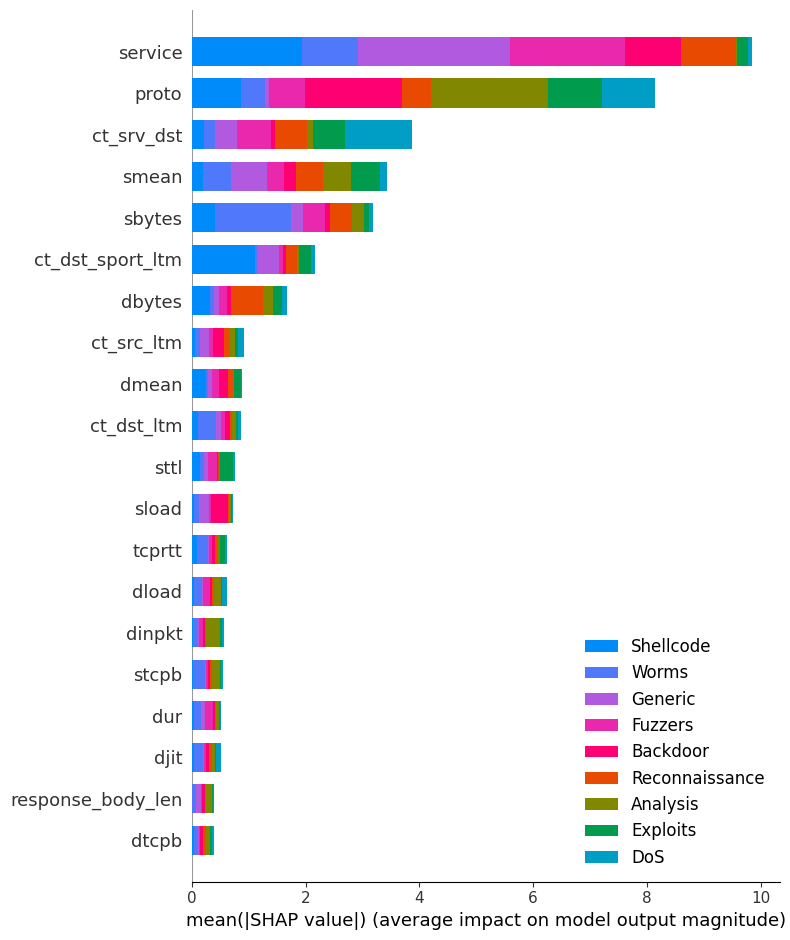

In [15]:
TestCatDMatrix = xgb.DMatrix(TestXAttackOnly, enable_categorical=True)
CatBooster = CategoricalLoaded.get_booster()
CatBooster.set_param({'device': 'cuda'})
ShapCatContrib = CatBooster.predict(TestCatDMatrix, pred_contribs=True)

NumClasses = ShapCatContrib.shape[1]

ShapValuesList = [ShapCatContrib[:, i, :-1] for i in range(NumClasses)]

XPlot = TestXAttackOnly.copy()
for col in XPlot.select_dtypes(include=['category']).columns:
    XPlot[col] = XPlot[col].cat.codes

ClassNames = [str(c) for c in CategoricalTargetEncoder.classes_]

shap.summary_plot(ShapValuesList, XPlot, class_names=ClassNames)